In [ ]:
import sys
sys.path.append("/home/delfina/projects/palace-course/utils")
#from verify_topology import verify, print_report
from ihp import PDK
from ihp.cells.inductors import inductor2
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
#yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

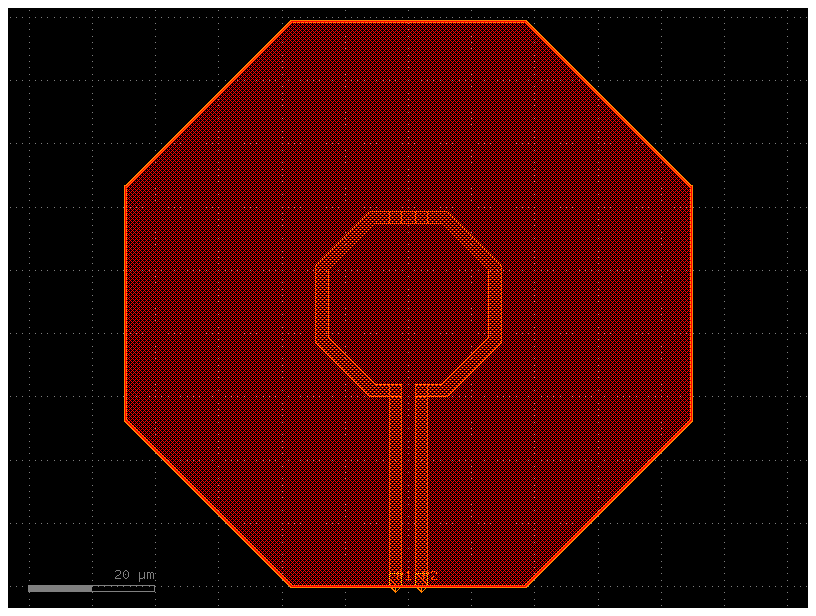

In [ ]:
c = inductor2()

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()

In [ ]:
# Checking the port layers.
cc.ports

["Port(self.name='P1', self.width=2000, trans=r270 *1 -2.05,0, layer=TopMetal2pin (134/2), port_type=electrical)", "Port(self.name='P2', self.width=2000, trans=r270 *1 2.05,0, layer=TopMetal2pin (134/2), port_type=electrical)"]

In [ ]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-inductor2")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=2.0,air_above=12.0)

sim.add_port("P1",to_layer="INDdrawing",from_layer="topmetal2",geometry="via")
sim.add_port("P2",to_layer="INDdrawing",from_layer="topmetal2",geometry="via")

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [ ]:
#sim.mesh(preset="default")

In [ ]:
sim.mesh(preset="default",margin=0.0, refined_mesh_size=1.0)

Mesh Summary
Dimensions: 29.4 x 59.4 x 30.3 µm
Nodes:      2,346
Elements:   17,190
Tetrahedra: 12,097
Edge length: 0.40 - 19.53 µm
Quality:    0.617 (min: 0.022)
SICN:       0.662 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (7):
  - topmetal2_xy [4]
  - topmetal2_z [5]
  - SiO2__None [6]
  - SiO2__passive [7]
  - passive__None [8]
  - air__passive [9]
  - air__None [10]
----------------------------------------
Mesh:   runs/palace-sim-inductor2/palace.msh

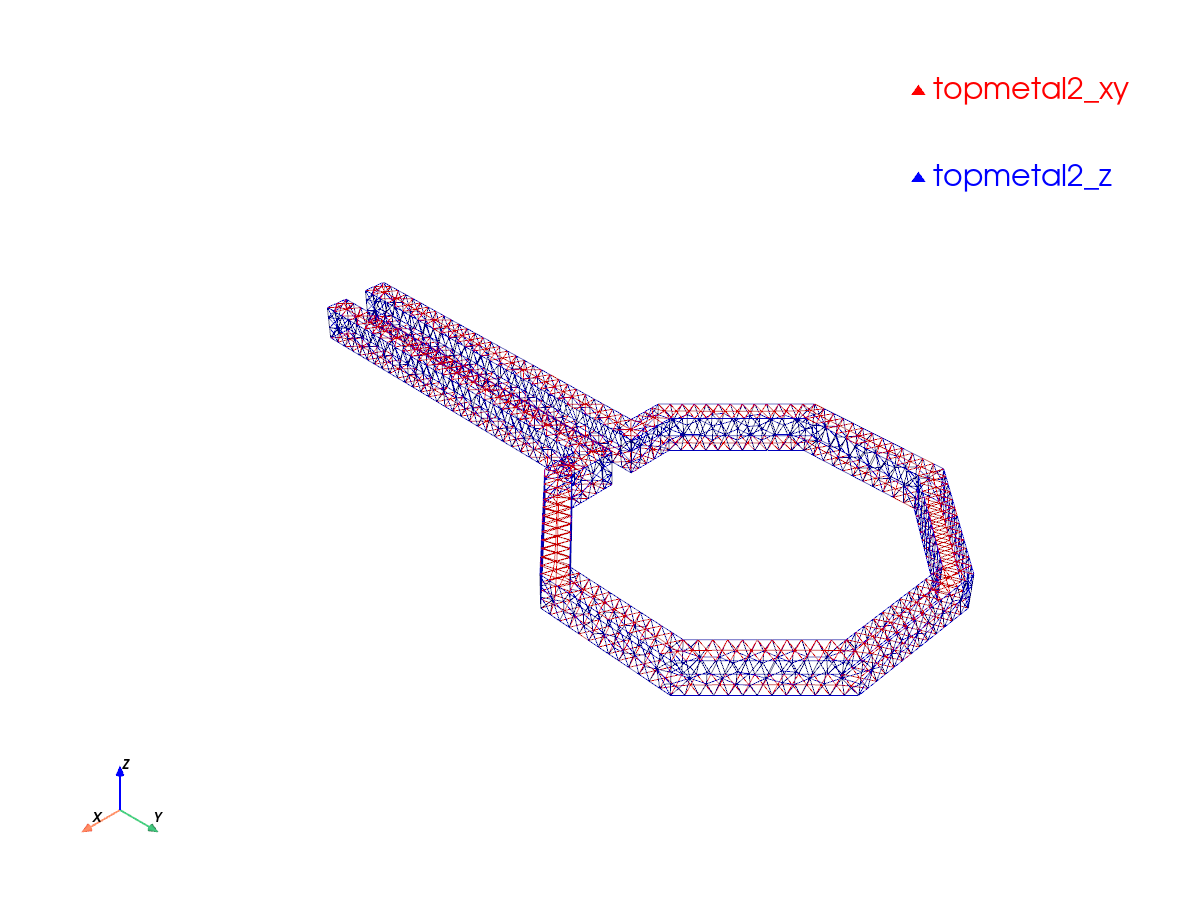

In [ ]:
sim.plot_mesh(show_groups=["metal","P"],interactive=False)

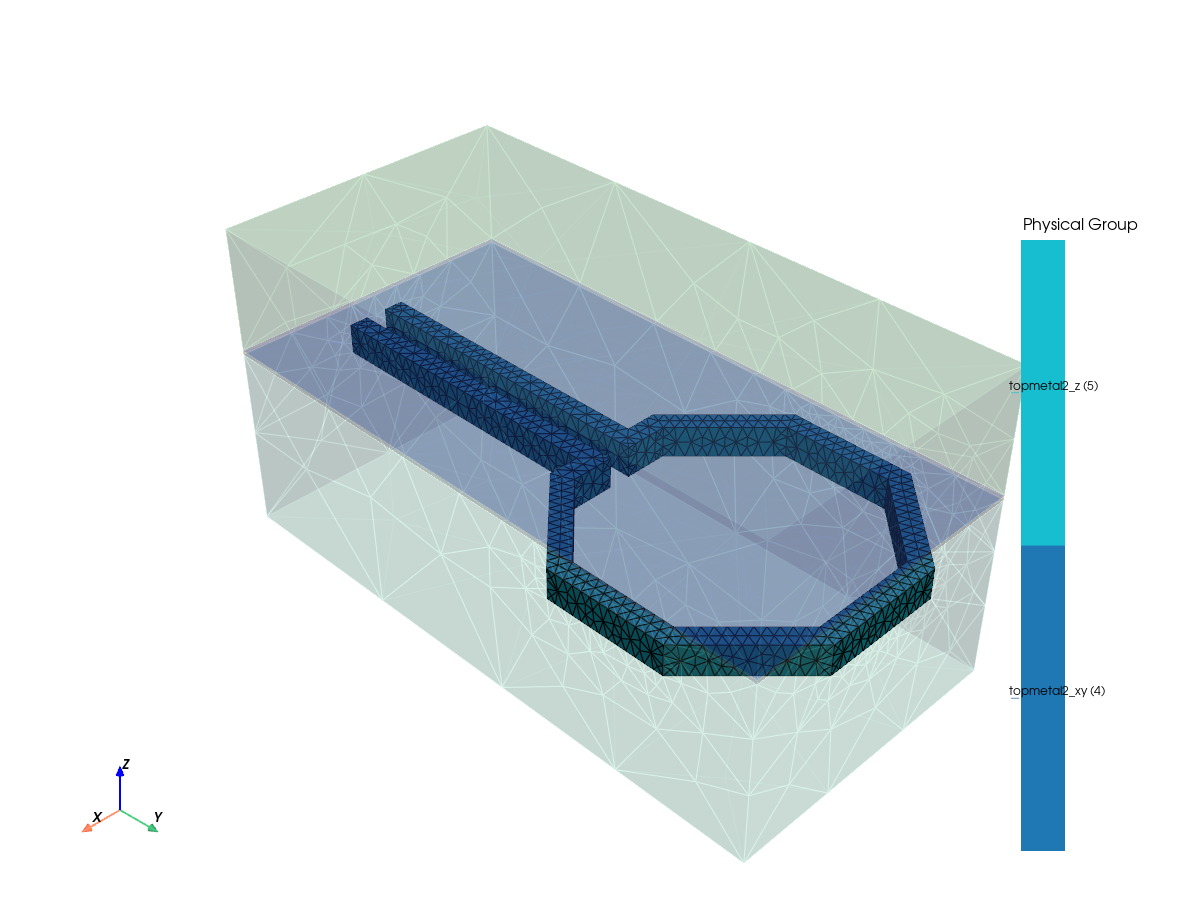

In [ ]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["air__None","air__passive","SiO2__None","SiO2__passive","passive__None"],
)

In [ ]:
sim.write_config()
results = sim.run_local()

ValueError: Mesh validation failed:
Validation: FAILED
Errors:
  - No port surfaces in mesh.
  - config.json has no LumpedPort nor Waveport entries.
Warnings:
  - Volumes: ['SiO2', 'passive', 'air']
  - Conductor surfaces: ['topmetal2_xy', 'topmetal2_z']

In [ ]:
result = verify(
    "runs/palace-sim-inductor2/palace.msh",
    "runs/palace-sim-inductor2/config.json"
)
print_report(result)



╔══════════════════════════════════════════════════════════════════════╗
║              Mesh Topological Consistency Report                    ║
╚══════════════════════════════════════════════════════════════════════╝

  Mesh file:             runs/palace-sim-inductor2/palace.msh
  Vertices:              2,481
  Tetrahedra:            12,546
  Boundary triangles:    4,428
  Unique volume faces:   25,726
    interior (2 tets):   24,458
    skin     (1 tet):    1,268

  Physical groups (2-D):
    attr   1 = SiO2
    attr   2 = passive
    attr   3 = air
    attr   4 = topmetal2_xy
    attr   5 = topmetal2_z
    attr   6 = P1
    attr   7 = P2
    attr   8 = SiO2__None
    attr   9 = SiO2__passive
    attr  10 = passive__None
    attr  11 = air__passive
    attr  12 = air__None

──────────────────────────────────────────────────────────────────────
  CHECK 1  —  Totality:  every boundary face ∈ volume faces
              (violation → MFEM abort: (r,c,f) = …)
────────────────────────────

True

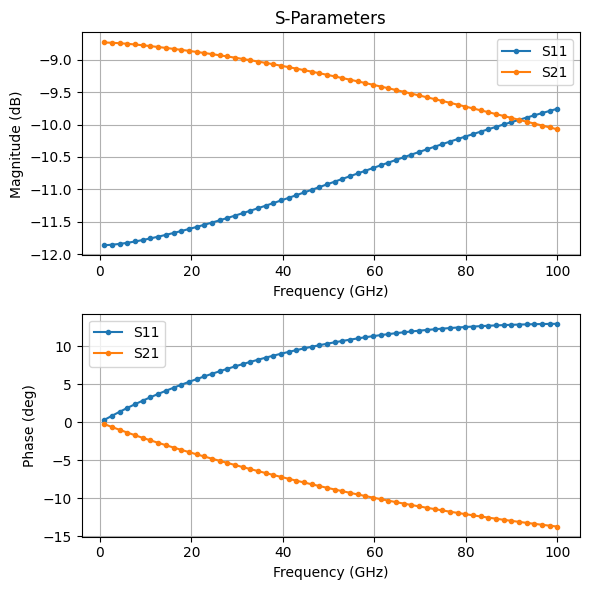

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()